# ¡Hola Cristian!

Mi nombre es Israel, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>

**Es un gusto acompañarte en este proceso, ¡empecemos!**

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


 **Hallazgos:**
 - No existen valores nulos en las columnas del dataframe.
 - Los datos de la columna `date` son de tipo 'object', el cual debería ser tipo 'date'.

In [5]:
# Transformar columna date con el tipo de dato correcto y verificar cambio
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [6]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [7]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [8]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [9]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [10]:
# Resumen estadístico de usuarios que se convirtieron
users_con = df[df['converted'] == 1]
users_con['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [11]:
# Explorar variables categóricas y cómo se distribuyen
col_categoricas = ['landing',
          'region',
          'dispositivo',
          'traffic_source',
          'user_type']
print("\nConteo de categorías")
for col in col_categoricas:
    print(col,":")
    print(df[col].value_counts(normalize=True) * 100)
    print() # salto de linea



Conteo de categorías
landing :
B    50.045
A    49.955
Name: landing, dtype: float64

region :
Norte        27.9150
Centro       24.0325
Sur          20.0975
Occidente    15.9950
Oriente      11.9600
Name: region, dtype: float64

dispositivo :
Mobile     62.0725
Desktop    37.9275
Name: dispositivo, dtype: float64

traffic_source :
Organic     44.9675
Ads         29.8375
Email       15.3075
Referral     9.8875
Name: traffic_source, dtype: float64

user_type :
Nuevo         65.0825
Recurrente    34.9175
Name: user_type, dtype: float64



**Hallazgos:**

- Todas las columnas tienen valores esperados.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Buen trabajo. Sin embargo, en `col_categoricas` revisas `landing`, `region`, `dispositivo`, `traffic_source` y `user_type`, pero omites `converted`

</div>


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:

# Gasto por versión
gasto_A = users_con[(users_con['landing'] == 'A')]['gasto']
gasto_B = users_con[(users_con['landing'] == 'B')]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)


(2512, 3194)

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** Afirma que no existe una diferencia real en el promedio de gasto entre los usuarios que compraron en cada página. 
- **Hipótesis alternativa (H₁):** Afirma que existe una diferencia real en el promedio de gasto entre los usuarios que compraron en cada página.

In [13]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)


# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")


Estadístico : -9.48101092267275
Valor p: 3.627602231521493e-21


In [14]:
# Calculamos promedio de gasto por grupo

promedio_A = gasto_A.mean()
promedio_B = gasto_B.mean()
print('Promedio gasto página A:', promedio_A)
print('Promedio gasto página B:', promedio_B)

Promedio gasto página A: 61.0865724522293
Promedio gasto página B: 68.74536005009392


In [15]:
# Mostramos diferencia entre promedios

diferencia = promedio_B - promedio_A
diferencia_porcentual = (diferencia / promedio_A) * 100

print('Diferencia de promedios:', diferencia)
print('Diferencia porcentual de promedios:', diferencia_porcentual)

Diferencia de promedios: 7.658787597864624
Diferencia porcentual de promedios: 12.537595891231124


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza hipóstesis nula. 

**Interpretación de negocio:**  
El resultado aplicado en la prueba t indica una diferencia significativa, además el valor p es muy bajo, no superando el valor de significancia estandar (0.05) lo que indica que el resultado no es producto del azar. La diferencia de promedio de gasto indica que hay una mayor actividad de gasto en la página B lo que puede traducirse en la probabilidad de que haya una mejor experiencia de compra en esta página.


---

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Buen trabajo. Filtras correctamente a los usuarios convertidos. Sin embargo, falta la prueba de Levene

</div>



## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** Afirma que no existe una diferencia real en la tasa de conversión entre ambos grupos (son variables independientes).
- **Hipótesis alternativa (H₁):** Afirma que existe una diferencia real en la tasa de conversión entre ambos grupos (no son variables independientes). 

In [16]:

# Número de usuarios convertidos por página
convertidos = df[df['converted']== 1]['landing'].value_counts()

# Total de usuarios por página
total_usuarios = df['landing'].value_counts()

print("\nUsuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", total_usuarios)




Usuarios convertidos por página:
 B    3194
A    2512
Name: landing, dtype: int64

Total de usuarios por página:
 B    20018
A    19982
Name: landing, dtype: int64


In [17]:
tasa_paginaA = (convertidos['A']) / (total_usuarios['A']) *100
tasa_paginaB = (convertidos['B']) / (total_usuarios['B']) *100

#verificar taza de conversión
print('tasa de conversión página A:', tasa_paginaA)
print() # salto de linea
print('tasa de conversión página B:', tasa_paginaB)

tasa de conversión página A: 12.571314182764487

tasa de conversión página B: 15.955639924068338


In [18]:
# Aplicar prueba
conversiones = [convertidos['A'], convertidos['B']]
totales = [total_usuarios['A'],total_usuarios['B']]

z_stat, p_value = proportions_ztest(conversiones, totales)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza hipóstesis nula. 

**Interpretación de negocio:**  
el resultado en la prueba de proporciones (prueba-z) implica una diferencia significativa, además el valor p es muy bajo, no superando el valor de significancia estandar (0.05) lo que indica que es poco probable que el resultado sea producto del azar. Sin embargo, la diferencia es de tan solo 3 puntos porcentuales aproximadamente, por lo que vale la pena cuestionar si alguna implementación de mejora es valiosa.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Excelente trabajo. Calculas correctamente lo solititado, muestras las tasas y aplicas `proportions_ztest`

</div>


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** Afirma que no existe una asociación significativa entre la fuente de tráfico y la conversión.
- **Hipótesis alternativa (H₁):** Afirma que existe una asociación significativa entre la fuente de tráfico y la conversión.

In [19]:

# Crear tabla de contingencia para aplicar la prueba
tabla = pd.crosstab(df['traffic_source'], df['converted'])
tabla_normalizada = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100


In [20]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"Estadístico chi-cuadrado: {chi2_stat}")
print(f"Valor P: {p_value}")


Estadístico chi-cuadrado: 8.662108841397938
Valor P: 0.0341375947833914


In [21]:
tabla

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [22]:
tabla_normalizada

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
 La prueba chi-cuadrada indica que existe una diferencia significativa entre el resultado observado y el esperado. Adicionalmente el valor-p no supera el umbral de significancia (menor que 0.05), lo que indica que es poco probable que el resultado sea producto del azar. 
- Los totales absolutos nos muestran que el canal más utiizado por los usuarios es **Organic** al contrario que **Referral**, el cual fue el menos usado.
- La tasa de conversión es similar entre los distintos canales. 

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Buen trabajo. Construyes correctamente las tablas absoluta y normalizada

</div>


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** Afirma que no existe una asociación significativa entre el tipo de usuario y la conversión.
- **Hipótesis alternativa (H₁):** Afirma que existe una asociación significativa entre el tipo de usuario y la conversión.

In [23]:
# Crear tabla de contingencia para aplicar la prueba
tabla_user = pd.crosstab(df['user_type'], df['converted'])
tabla_user_normalizada = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100

In [24]:
tabla_user

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [25]:
tabla_user_normalizada

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


In [26]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_user)
print(f"Estadístico chi-cuadrado: {chi2_stat}")
print(f"Valor P: {p_value}")


Estadístico chi-cuadrado: 0.5134849494478645
Valor P: 0.4736341272301974


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza hipótesis nula.

**Interpretación de negocio:**  
La prueba indica que los valores observados y los esperados no difieren en gran medida. El valor-p supera el umbral de significancia (mayor que 0.05) por lo cual no hay evidencia suficiente para afirmar que existen diferencias. 

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Excelente trabajo. Construyes correctamente las tablas absoluta y normalizada de `user_type` y la prueba chi-cuadrada es correcta

</div>


## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

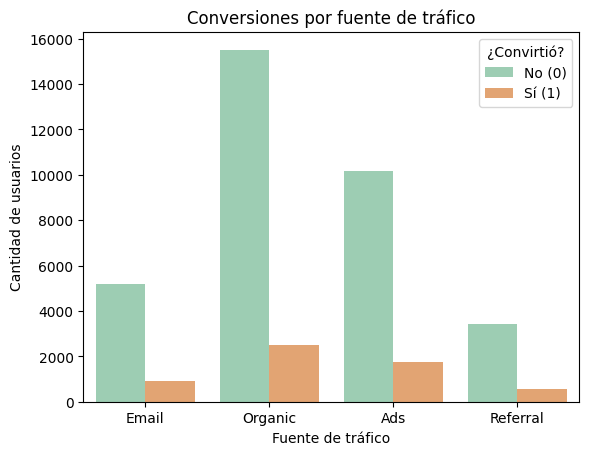

In [27]:
sns.countplot(data=df, x='traffic_source', hue='converted', palette=["#95D5B2", "#F4A261"])
plt.title('Conversiones por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

✍️ **Comentario**: 

El gráfico nos muestra que la mayor cantidad de usuarios se canalizaron por **Organic**, el cual tiene el mayor número de conversiones. Por otro lado **Referral** registra el menor número de usuarios canalizados así como el número de conversiones. La visualización apoya los resultado obtenidos previamente en números.

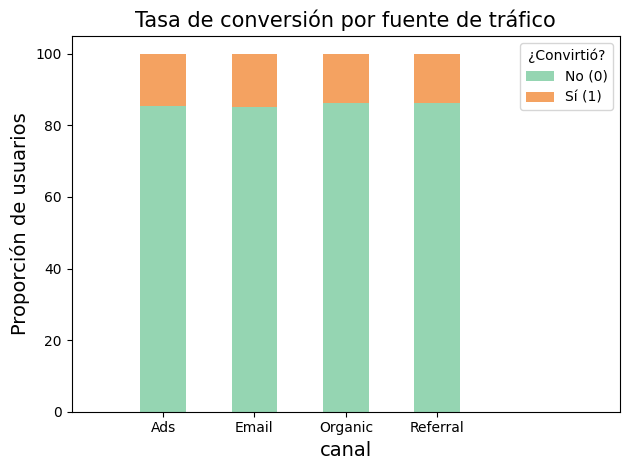

In [32]:
tabla_normalizada.plot(kind='bar', stacked=True, color=["#95D5B2", "#F4A261"])

plt.title('Tasa de conversión por fuente de tráfico', fontsize=15)
plt.xlabel('canal', fontsize=14)
plt.ylabel('Proporción de usuarios', fontsize=14)
plt.xlim(-1, 5)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
plt.tick_params(rotation=0)

plt.tight_layout()
plt.show()

✍️ **Comentario**: 

La tasa de conversión por cada canal mantiene una proporción simétrica respecto a las demás.

### Relación entre el tipo de usuario y la conversión

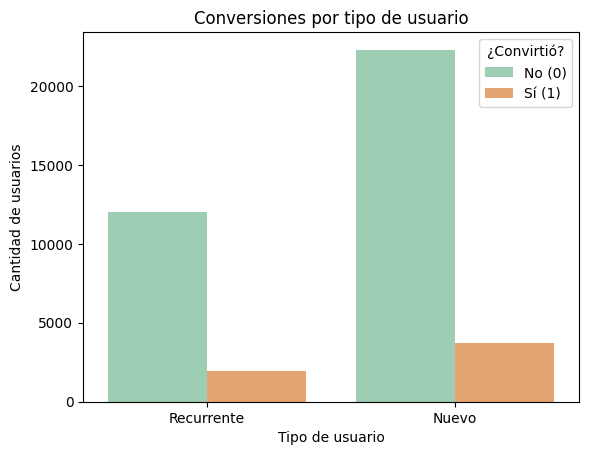

In [29]:
sns.countplot(data=df, x='user_type', hue='converted', palette=["#95D5B2", "#F4A261"])
plt.title('Conversiones por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

✍️ **Comentario**: 

Los usuarios nuevos tienden a generar mayor cantidad de conversiones.

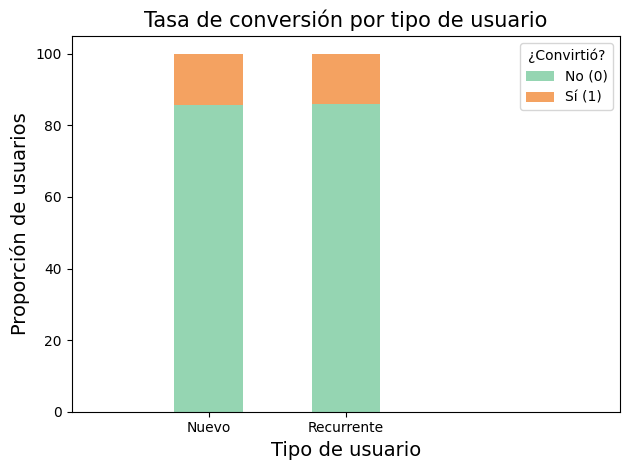

In [33]:
tabla_user_normalizada.plot(kind='bar', stacked=True, color=["#95D5B2", "#F4A261"])

plt.title('Tasa de conversión por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario', fontsize=14)
plt.ylabel('Proporción de usuarios', fontsize=14)
plt.xlim(-1, 3)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
plt.tick_params(rotation=0)

plt.tight_layout()
plt.show()

✍️ **Comentario**: 

Nuevamente la tasa de conversión es simétrica entre ambos tipos de usuarios.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Las cuatro visualizaciones requeridas están presentes y correctamente construidas

</div>


## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
1. El gasto promedio muestra una diferencia de aproximadamente 8 unidades monetarias siendo el grupo B el que mayor promedio registra. 
2. Porcentualmente existe una diferencia de aproximadamente el 13% en el gasto promedio.
    
- **Interpretación:**

Es posibe que la experiencia de usuario sea mejor en la página B; atractivo de interfaz, faicilidad de navegación, etc. 

**Tasa de conversión:** 
- La tasa de conversión en la página A es de aproximadamente 13% mientras que en la página B es del 16%.
- La diferencia en la tasa de conversión entre ambas paginas es de aproximadamente 3 puntos porcentuales, nuevamente predominando en el grupo B la mayor tasa de conversión.

- **Interpretación:**

La diferencia indica que la experiencia de compra es mejor en la página B. Pueden existir diferencias que hacen que los usuarios se pierdan menos en los pasos de compra en la interfaz; métodos de pago, lista de productos, información a diligenciar, etc.

---

#### 📊 **Segmentación por fuente de tráfico**
- Organic y ADS son las fuentes que más usuarios canalizan, sin embargo, la tasa de conversión es simétrica en todos las fuentes de trafico.
  
- **Interpretación:**

Ningún canal convierte más que otro, sin embargo existen preferencias por parte de los usuarios por los canales mencionados.

 ---

#### 📊 **Segmentación por tipo de usuario**
- Los usuarios nuevos generan mayor cantidad de conversiones, sin embargo, la tasa de conversión se mantiene simétrica entre ambos grupos.
  
- **Interpretación:**

Las promociones u ofertas en los productos funcionan mejor para atraer cliente nuevos.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Revisar la diferencia de limitaciones entre las versiones de la página A y la página B así como el proceso de compra el cual es más efecctivo en la página B. 

- Revisar el stock de productos buscados por usuarios recurrentes donde haya mayor coincidencia para generar promociones o incluso entender que están buscando realmente para incrementar la probabilidad de compra.